### Deep Agents overview

Build agents that can plan, use subagents, and leverage file systems for complex tasks\n","\n","deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

### When to use deep agents

Use deep agents when you need agents that can:
- Handle complex, multi-step tasks that require planning and decomposition\n","
- Manage large amounts of context through file system tools\n","
- Delegate work to specialized subagents for context isolation\n","
- Persist memory across conversations and threads

In [ ]:
### Basic deep agents
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [8]:
from tavily import TavilyClient
from typing import Literal
tavily_client = TavilyClient(api_key = os.getenv("TAVILY_API_KEY"))

def web_search(query:str, max_results:int=5, 
topic:Literal["Sports","News","Finance"] = "General", include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results = max_results, include_raw_content = include_raw_content)



In [20]:
from langchain.chat_models import init_chat_model
model = init_chat_model("groq:qwen/qwen3.6-27b")

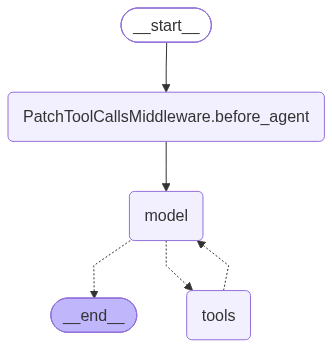

In [22]:
## Create a deep agent

## Prompt

## agent

from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher",
)

deepagent

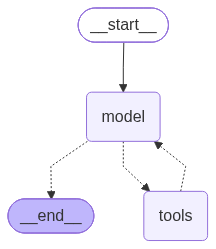

In [19]:
## Basic Agent
from langchain.agents import create_agent

simple_agent = create_agent(model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)

simple_agent

In [24]:
result=deepagent.invoke({"messages":[{"role":"user", "content":"what is deep agent?"}]})
result

{'messages': [HumanMessage(content='what is deep agent?', additional_kwargs={}, response_metadata={}, id='4a075f4a-460a-478c-aba0-bf23f34bab9a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking about "deep agent". This could refer to several things:\n1.  Deep Agent (a specific software company or project).\n2.  A concept in AI/ML (Deep Learning Agents).\n3.  A specific library or tool in Python (e.g., `deepagent`).\n4.  "Deep Agent" as a general term in cybersecurity or other fields.\n\nI should probably explain the general concept of "Deep Learning Agents" or "Deep Agents" in the context of AI, as that is the most likely intent given the "researcher" persona. I should also check if there are specific libraries or companies with that name to provide a comprehensive answer.\n\nPlan:\n1.  Define the general concept of Deep Agents (AI agents using deep learning).\n2.  Search for specific tools/libraries named "deep agent" or "deepagent" to see if there\

In [26]:
result["messages"][-1].content

'In the context of modern artificial intelligence, a **Deep Agent** is an advanced AI system designed to handle complex, open-ended, and long-running tasks autonomously. \n\nUnlike standard AI chatbots or "shallow" agents that rely solely on a conversation history (context window) to answer questions or perform simple, single-step actions, deep agents are structured like project managers. They actively plan, remember, and delegate work over extended periods to solve difficult problems.\n\nHere is a breakdown of what makes an agent "deep":\n\n### 1. Explicit Planning\nDeep agents do not just react to prompts. They actively break down a complex goal into a step-by-step plan. If they encounter a roadblock or new information, they can dynamically adapt their plan and continue toward the ultimate goal.\n\n### 2. Persistent Memory and External Workspaces\nStandard agents often "forget" things once a conversation gets too long because they hit the limits of their context window. Deep agents o

In [28]:
result['files']

{}